<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_Ensemble/18_5_1_Trees_Data_and_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees: The Foundation of Ensembles

**Author:** Brad Sheese

---

## Introduction

In 18_1_5, we were introduced to decision trees in the context of regression (predicting house prices). This notebook revisits trees for **classification** — predicting whether a breast tumor is malignant or benign.

The core mechanics are the same: the tree asks yes/no questions to split the data. But there are key differences:

| | Regression Tree (18_1_5) | Classification Tree (this notebook) |
|---|---|---|
| **Leaf prediction** | Mean of target values in the leaf | Majority class in the leaf |
| **Split criterion** | Minimizes Mean Squared Error (MSE) | Minimizes Gini impurity (or entropy) |
| **Evaluation** | R², MSE | Accuracy, precision, recall, F1, ROC AUC |

In classification, we need precision, recall, F1, and the ROC curve — especially in a medical context where false negatives (missing a cancer) are far more costly than false positives.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Load and explore the Wisconsin Breast Cancer dataset.
2. Implement a Decision Tree classifier using scikit-learn.
3. Visualize the model's decision-making process with a tree diagram.
4. Evaluate the impact of tree depth on model accuracy, recall, and overfitting.
5. Interpret the confusion matrix, precision, recall, and F1-score in a medical context.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, recall_score, f1_score

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Preparation: Wisconsin Breast Cancer Dataset

Measurements from digitized images of fine needle aspirates (FNA) of breast masses. Features describe characteristics of cell nuclei.

- **569 samples**, **30 features** (mean, SE, and "worst" for 10 cell nucleus characteristics)
- **Target**: Malignant (1) or Benign (0) — we flip sklearn's encoding so 1 = malignant
- **Class distribution**: ~63% benign, ~37% malignant

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

# Flip target: 1=malignant, 0=benign (matching original UCI encoding)
df['target'] = 1 - df['target']

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['target'].value_counts(normalize=True))
print(f"\nTarget names: 1 = Malignant, 0 = Benign")

Dataset shape: (569, 31)

Target distribution:
target
0    0.627417
1    0.372583
Name: proportion, dtype: float64

Target names: 1 = Malignant, 0 = Benign


### Visualizing Key Feature Distributions

Trees don't care about skew or scaling — unlike linear regression, we don't need to transform features. But let's still look at the most discriminative features to understand what separates malignant from benign tumors.

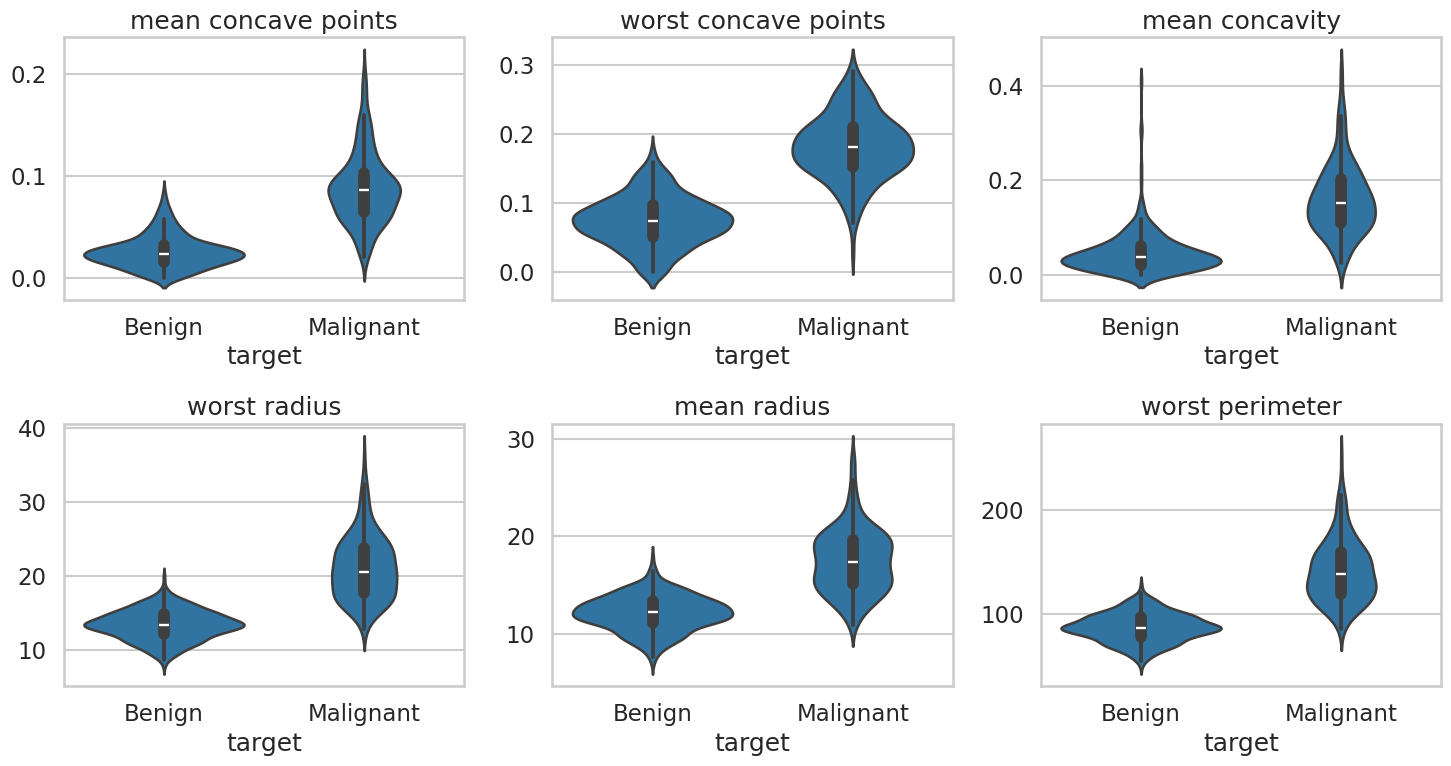

Good differentiation means the two distributions have minimal overlap.
Notice how 'mean concave points' shows the clearest separation.


In [3]:
# Show violin plots for the top 6 most discriminative features
key_features = [
    'mean concave points', 'worst concave points', 'mean concavity',
    'worst radius', 'mean radius', 'worst perimeter'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.violinplot(x='target', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benign', 'Malignant'])
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

print("Good differentiation means the two distributions have minimal overlap.")
print("Notice how 'mean concave points' shows the clearest separation.")

### Train/Test Split

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Test set class ratio: {y_test.mean():.1%} malignant, {(1-y_test.mean()):.1%} benign")

Training set size: 398
Testing set size: 171
Test set class ratio: 37.4% malignant, 62.6% benign


---
## 2. A Single Decision Tree

We'll start with a tree limited to `max_depth=3` to keep it interpretable. But first, let's understand **how the tree chooses its splits**.

### How Trees Choose Splits: Gini Impurity

At each node, the tree tries every possible split on every feature and picks the one that produces the **purest** child nodes. Purity is measured by **Gini impurity**:

$$Gini = 1 - \sum_{i=1}^{K} p_i^2$$

Where $p_i$ is the proportion of class $i$ in the node. For our binary case:
- **Gini = 0**: The node is pure (all one class)
- **Gini = 0.5**: The node is maximally mixed (50/50 split)

**Example:** A node with 80 malignant and 20 benign: Gini = 1 - (0.8² + 0.2²) = 0.32. A split that separates them into (75 malignant, 5 benign) and (5 malignant, 15 benign) would produce child nodes with Gini = 0.12 and Gini = 0.38 — a net improvement.

**Note:** scikit-learn uses Gini impurity by default. The alternative is **entropy** (information gain). In practice, they produce nearly identical trees.

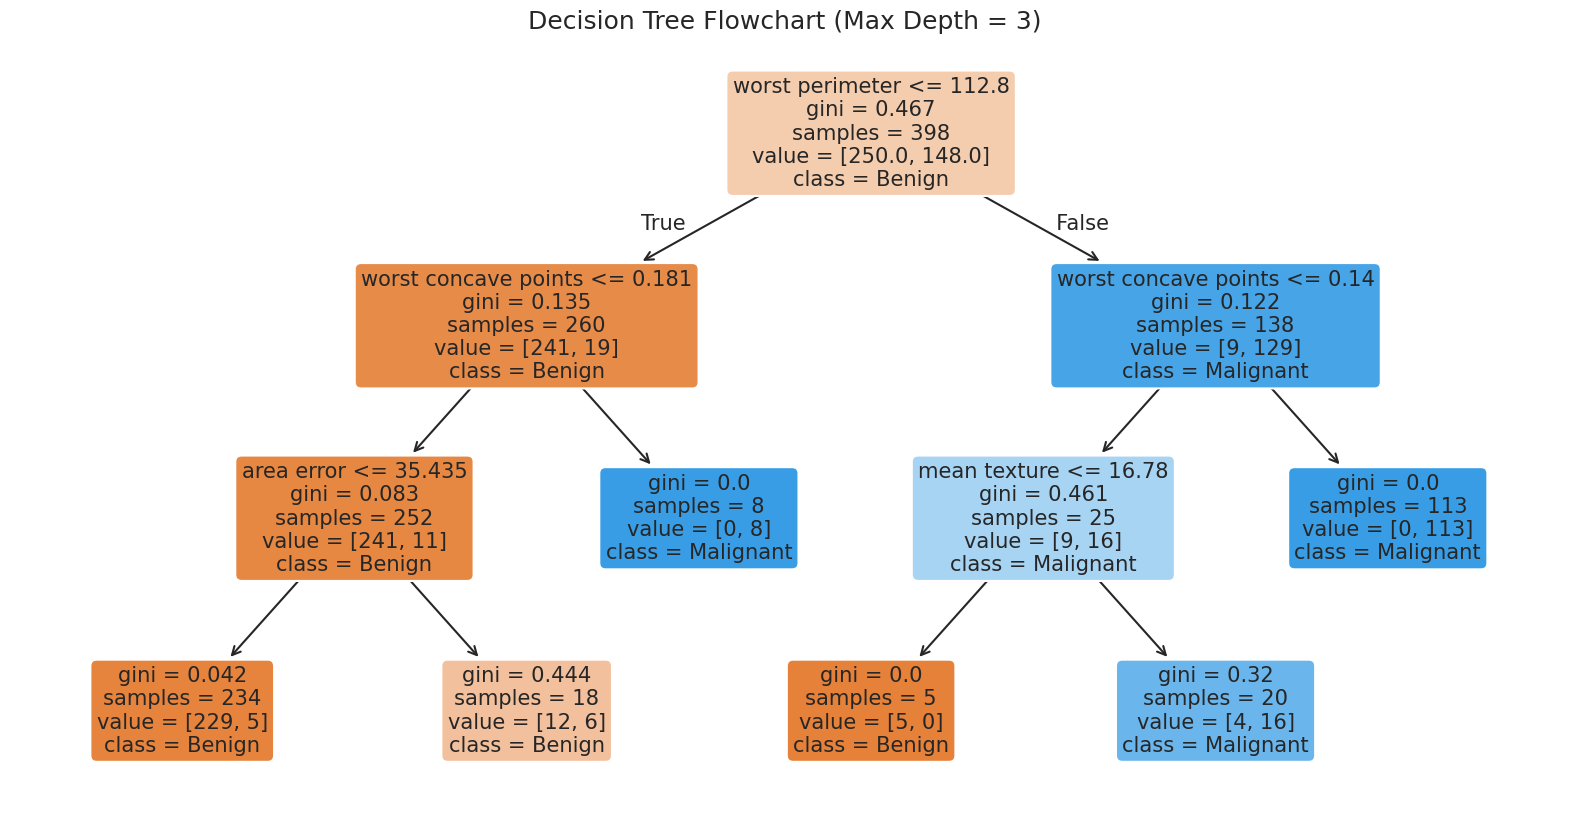

In [5]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=data.feature_names,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True)
plt.title("Decision Tree Flowchart (Max Depth = 3)")
plt.show()

### How to Read the Tree

Each node shows:
1. **Condition**: The question (e.g., `mean concave points <= 0.051`). True → left, False → right.
2. **Gini**: Impurity measure. 0.0 = pure (one class), 0.5 = maximally mixed.
3. **Samples**: Number of patients in this node.
4. **Value**: `[benign count, malignant count]`.
5. **Class**: The predicted class (majority vote).
6. **Color**: Orange = benign, Blue = malignant. Darker = purer.

Notice that the root node splits on `mean concave points <= 0.051` — exactly the feature we identified earlier as having the clearest separation between classes.

---
## 3. The Overfitting Problem: Depth vs. Generalization

As we saw in 18_1_5, an unconstrained tree will memorize the training data. Let's verify this with our classification data — and this time, let's also track **recall for the malignant class**, since missing cancers is our biggest concern.

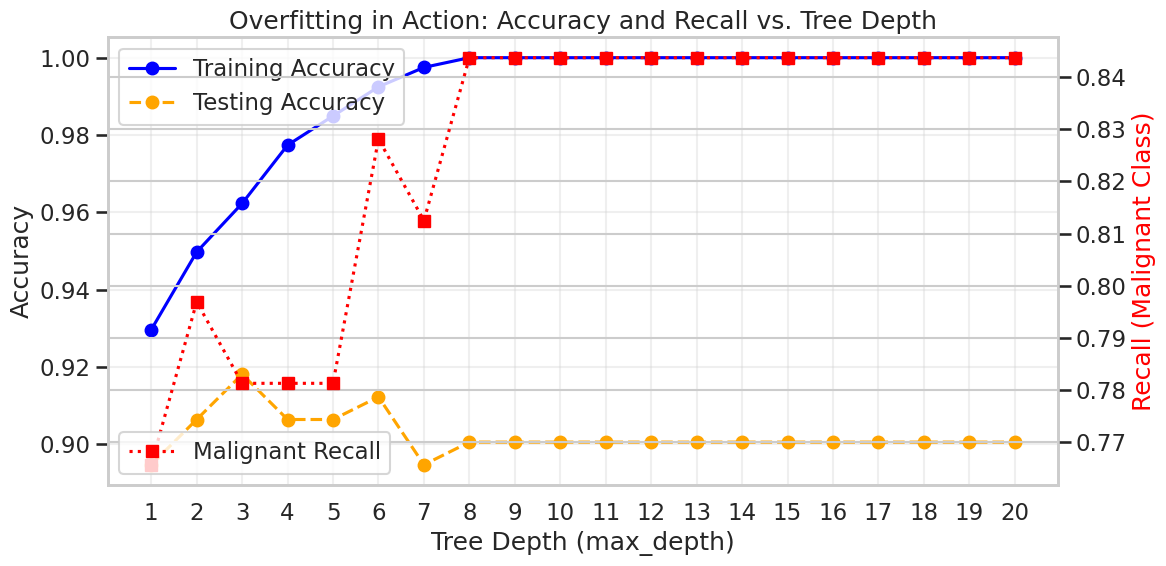

Best Testing Accuracy at Depth: 3 (Acc = 0.918)
Best Malignant Recall at Depth: 8 (Recall = 0.844)


In [6]:
depths = range(1, 21)
train_scores = []
test_scores = []
test_recalls = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))
    test_recalls.append(recall_score(y_test, tree.predict(X_test)))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(depths, train_scores, label='Training Accuracy', marker='o', linestyle='-', color='blue')
ax1.plot(depths, test_scores, label='Testing Accuracy', marker='o', linestyle='--', color='orange')
ax1.set_xlabel('Tree Depth (max_depth)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Overfitting in Action: Accuracy and Recall vs. Tree Depth')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(depths, test_recalls, label='Malignant Recall', marker='s', linestyle=':', color='red')
ax2.set_ylabel('Recall (Malignant Class)', color='red')
ax2.legend(loc='lower left')

plt.xticks(depths)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_scores)]
best_recall_depth = depths[np.argmax(test_recalls)]
print(f"Best Testing Accuracy at Depth: {best_depth} (Acc = {test_scores[best_depth-1]:.3f})")
print(f"Best Malignant Recall at Depth: {best_recall_depth} (Recall = {test_recalls[best_recall_depth-1]:.3f})")

### Analyzing the Complexity Curve

- **Training accuracy** (blue solid line) climbs to 1.0 — the tree memorizes the training data.
- **Testing accuracy** (orange dashed line) peaks then plateaus or drops — the model stops generalizing.
- **Malignant recall** (red dotted line) shows how many actual cancers the model catches. Notice it may peak at a different depth than accuracy.

The **gap** between training and testing accuracy is the overfitting penalty. In a medical context, the recall curve is arguably more important than accuracy: we need to catch as many cancers as possible.

This is the same bias-variance pattern we saw in 18_1_5 with the Ames data, now expressed through tree depth in a classification context.

---
## 4. Beyond Accuracy: Classification Metrics

In a medical diagnosis context, accuracy alone is dangerous. Let's evaluate our best-depth tree using the full suite of metrics we learned in 18_1_1 and 18_1_2.

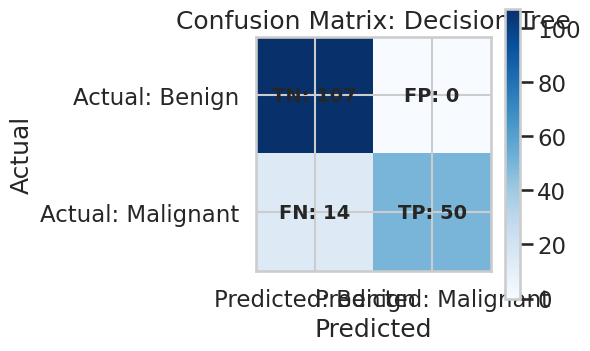


--- Medical Interpretation ---
False Negatives (missed cancers): 14
False Positives (unnecessary biopsies): 0

In a real clinical setting, each false negative represents a cancer that goes undiagnosed.
Each false positive represents a patient who undergoes an unnecessary biopsy.

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.88      1.00      0.94       107
Malignant (1)       1.00      0.78      0.88        64

     accuracy                           0.92       171
    macro avg       0.94      0.89      0.91       171
 weighted avg       0.93      0.92      0.92       171



In [7]:
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Benign', 'Predicted: Malignant'])
ax.set_yticklabels(['Actual: Benign', 'Actual: Malignant'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Decision Tree')

labels = [[f'TN: {tn}', f'FP: {fp}'], [f'FN: {fn}', f'TP: {tp}']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n--- Medical Interpretation ---")
print(f"False Negatives (missed cancers): {fn}")
print(f"False Positives (unnecessary biopsies): {fp}")
print(f"\nIn a real clinical setting, each false negative represents a cancer that goes undiagnosed.")
print(f"Each false positive represents a patient who undergoes an unnecessary biopsy.")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

### ROC Curve and AUC

Let's also look at the ROC curve, which shows the trade-off between true positive rate (recall) and false positive rate across all possible thresholds.

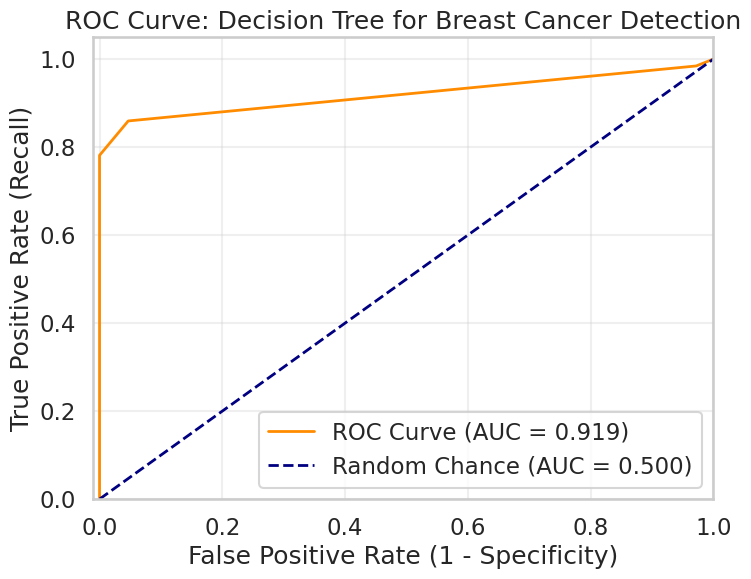

AUC = 0.919
Interpretation: If you randomly pick one malignant and one benign tumor,
the model correctly ranks the malignant one as higher-risk 91.9% of the time.


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.500)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Decision Tree for Breast Cancer Detection')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC = {roc_auc:.3f}")
print(f"Interpretation: If you randomly pick one malignant and one benign tumor,")
print(f"the model correctly ranks the malignant one as higher-risk {roc_auc*100:.1f}% of the time.")

---
## 5. Robust Evaluation: K-Fold Cross-Validation

A single train/test split can be misleading. Let's use 10-fold CV for a more reliable estimate — and this time, let's track accuracy, recall, and F1 together.

In [9]:
from sklearn.model_selection import cross_val_score, KFold

robust_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_acc = cross_val_score(robust_clf, X, y, cv=kf, scoring='accuracy')
cv_recall = cross_val_score(robust_clf, X, y, cv=kf, scoring='recall')
cv_f1 = cross_val_score(robust_clf, X, y, cv=kf, scoring='f1')

print(f"{'Metric':<15} {'Mean':<10} {'Std Dev':<10} {'Min':<10} {'Max':<10}")
print("-" * 55)
print(f"{'Accuracy':<15} {cv_acc.mean():.3f}      {cv_acc.std():.3f}      {cv_acc.min():.3f}      {cv_acc.max():.3f}")
print(f"{'Recall (Malig.)':<15} {cv_recall.mean():.3f}      {cv_recall.std():.3f}      {cv_recall.min():.3f}      {cv_recall.max():.3f}")
print(f"{'F1-Score':<15} {cv_f1.mean():.3f}      {cv_f1.std():.3f}      {cv_f1.min():.3f}      {cv_f1.max():.3f}")

print(f"\nIn a clinical setting, the malignant recall of {cv_recall.mean():.0%} means")
print(f"roughly 1 in {int(1/(1-cv_recall.mean()))} cancers would be missed by this model.")

Metric          Mean       Std Dev    Min        Max       
-------------------------------------------------------
Accuracy        0.940      0.025      0.895      0.982
Recall (Malig.) 0.913      0.058      0.824      1.000
F1-Score        0.915      0.040      0.848      0.981

In a clinical setting, the malignant recall of 91% means
roughly 1 in 11 cancers would be missed by this model.


### Your Turn

1. The classification report shows the malignant class recall. If this model screened 10,000 patients with the same cancer rate as our dataset, approximately how many cancers would be missed?
2. The ROC AUC is shown in the plot above. What does this mean in practical terms for a doctor using this model?
3. The CV recall standard deviation is printed above. Is this model stable enough for clinical use? What would you do to improve it?

## Conclusion

A single decision tree is interpretable but unstable. The depth experiment showed that training accuracy reaches 1.0 while test accuracy plateaus — classic overfitting. The classification metrics revealed that even our "best" tree misses some cancers (false negatives), which is unacceptable in a clinical setting.

In the next notebook, we'll solve this instability problem by combining many trees into an ensemble: **bagging and random forests**.